In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("vehicles.csv")

C:\Users\56961\AppData\Local\Temp\ipykernel_5412\3059042137.py:1: DtypeWarning: Columns (0: sCharger, 1: fuelType2, 2: rangeA, 3: evMotor, 4: mfrCode, 5: c240Dscr, 6: c240bDscr, 7: startStop) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("vehicles.csv")


# Adress issues shown by warning

In [3]:
df[df['sCharger'].notna()]['sCharger'] # Booleanize, it`s an important predictor for engine eficiency performance.

61       S
62       S
119      S
148      S
149      S
        ..
48852    S
48853    S
48912    S
48942    S
48944    S
Name: sCharger, Length: 1144, dtype: str

In [4]:
df[df['fuelType2'].notna()]['fuelType2'].unique() # Encode, E85 usually is for internal combustion engines, Natural gas and propane are alternates of eachother. Electricity is hybrid?

<StringArray>
['Natural Gas', 'E85', 'Propane', 'Electricity']
Length: 4, dtype: str

In [5]:
df[df['fuelType2'].notna()]['fuelType'].unique() # We will ignore fuelType2 as it is an alternate fuel option and is not widely available. We will only use fuelType1 from now on.

<StringArray>
[    'Gasoline or natural gas',             'Gasoline or E85',
         'Gasoline or propane',              'Premium or E85',
  'Premium Gas or Electricity', 'Regular Gas and Electricity',
     'Premium and Electricity',  'Regular Gas or Electricity']
Length: 8, dtype: str

# Further analysis from this point on will be made using only fuelType1 and all corresponding city, highway and mixed Mileage data.

All dual fuel cars are either BiFuel engined or hybrids. Note fuelType1 is manufacturers recomended fuel.

In [6]:
df[df['rangeA'].notna()]['rangeA'].unique() # Drop, it pertains to range of fuel type 2 per EPA measurments.

<StringArray>
[        '360',         '290', '230/270/270', '240/290/290',     '230/270',
     '240/280',     '220/260', '220/270/260', '240/290/280',         '300',
 ...
          '56',         '166',          '50',          '30',          '39',
           '1',          '43',          '44',          '41',           '6']
Length: 253, dtype: str

In [7]:
df[df['evMotor'].notna()]['evMotor'].unique() # Drop, we will not include electric vehicles in model.

<StringArray>
[              '62 KW AC Induction',                         '50 KW DC',
               '27 KW AC Induction',               '67 KW AC Induction',
             '24 KW AC Synchronous',                       '288V Ni-MH',
                       '330V Ni-MH',                        '36V Ni-MH',
                       '245V Ni-MH',                       '158V Ni-MH',
 ...
                    '68 kW AC PMSM',                      '205 kW DCPM',
         '175, 280 and 495 kW ACPM',     '87 and 167 kW AC Synchronous',
 '112, 112 and 155 kW AC Induction', '225 and 270 kW Asynchron 3-Phase',
              '130 kW ACPM 3-Phase',              '123 and 240 kW EESM',
                      '300 kW ACPM',                    '60 kW AC PMSM']
Length: 598, dtype: str

In [8]:
df[df['mfrCode'].notna()]['mfrCode'].unique() # Drop, we will use full manufacturer name and encode that.

<StringArray>
['ADX', 'BEX', 'NLX', 'TYX', 'PRX', 'ASX', 'CRX', 'DSX', 'BMX', 'FMX', 'NSX',
 'RII', 'VWX', 'HNX', 'HYX', 'SAX', 'VVX', 'TKX', 'KMX', 'GMX', 'MBX', 'RRG',
 'LRX', 'BGT', 'JCX', 'MAX', 'MTX', 'FJX', 'SKX', 'AZD', 'MLN', 'TVP', 'CDA',
 'LTX', 'FEX', 'FSK', 'TSL', 'BYD', 'JLX', 'VGA', 'SKR', 'MBV', 'FTG', 'QTM',
 'PGN', 'KAL', 'KGG', 'RAX', 'SUB', 'SCA', 'RIV', 'LMU', 'LEV', 'FGI', 'VTP',
 'IAL', 'BGR', 'PAB']
Length: 58, dtype: str

In [9]:
df[df['c240Dscr'].notna()]['c240Dscr'].unique() # Drop, we will not include electric vehicles in model.

<StringArray>
[  'single charger',   '3.6 kW charger', 'standard charger',
   '7.2 kW charger',   '6.6 kW charger']
Length: 5, dtype: str

In [10]:
df[df['c240bDscr'].notna()]['c240bDscr'].unique() # Drop, we will not include electric vehicles in model.

<StringArray>
[                                'dual charger',
                               '6.6 kW charger',
                          '80 amp dual charger',
                               '3.6 kW charger',
 'with 48A high power charger connector option',
                 'with 80A dual charger option',
 'with 72A high power charger connector option']
Length: 7, dtype: str

In [11]:
df[df['startStop'].notna()]['startStop'].unique() # Booleanize

<StringArray>
['Y', 'N']
Length: 2, dtype: str

# Fix issues addressed above

According to https://www.fueleconomy.gov/feg/ws/index.shtml#vehicle, as our source for data description, we will eliminate columns.  
For being related to electric vehicles the following columns will be droped:  
- charge120
- charge240
- cityE
- combE
- evMotor
- highwayE
- c240Dscr
- charge240b
- c240bDscr
  
For being related to fuel type 2, to simplify analysis we will only compare between primary fuel types, and not optional secondary fuel types. The following columns will be dropped:
- cityA08
- cityA08U
- co2A
- co2TailpipeAGpm
- combA08
- combA08U
- fuelCostA08
- fuelType (Contains both fuelType1 and fuelType2, will be dropped in favour of using only fuelType1 column)
- fuelType2
- ghgScoreA
- highwayA08
- highwayA08U
- rangeA
- rangeCityA
- rangeHwyA
- UCityA
- UHighwayA
  
For being unrelated to engine or car performance, the following columns will be dropped:
- barrels08
- barrelsA08
- engId
- fuelCost08
- id
- mpgData
- youSaveSpend

In [12]:
df.columns

Index(['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08',
       'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2',
       'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U',
       'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders',
       'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08',
       'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA',
       'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD',
       'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make',
       'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity',
       'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA',
       'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'baseModel',
       'guzzler', 'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2',
       'rangeA', 'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr',
       'createdOn'

In [13]:
cols_to_drop = [
    # EV / secondary fuel type
    'charge120', 'charge240', 'cityE', 'combE',
    'evMotor', 'highwayE', 'c240Dscr', 'charge240b', 'c240bDscr',
    # Alternative fuel (type 2) performance
    'cityA08', 'cityA08U', 'co2A', 'co2TailpipeAGpm',
    'combA08', 'combA08U', 'fuelCostA08', 'fuelType',
    'fuelType2', 'ghgScoreA', 'highwayA08', 'highwayA08U',
    'rangeA', 'rangeCityA', 'rangeHwyA', 'UCityA', 'UHighwayA',
    # Unrelated to engine / car performance
    'barrels08', 'barrelsA08', 'engId',
    'fuelCost08', 'id', 'mpgData', 'youSaveSpend', 'createdOn',
    'modifiedOn', 'baseModel'
]
df2 = df.drop(columns=cols_to_drop)

In [14]:
df2.head() # Dataframe after droping columns described above

,city08,city08U,cityCD,cityUF,co2,co2TailpipeGpm,comb08,comb08U,combinedCD,combinedUF,cylinders,displ,drive,eng_dscr,feScore,fuelType1,ghgScore,highway08,highway08U,highwayCD,highwayUF,hlv,hpv,lv2,lv4,make,model,phevBlended,pv2,pv4,range,rangeCity,rangeHwy,trany,UCity,UHighway,VClass,year,guzzler,trans_dscr,tCharger,sCharger,atvType,mfrCode,startStop,phevCity,phevHwy,phevComb
0,19,0.0,0.0,0.0,-1,423.190476,21,0.0,0.0,0.0,4.0,2.0,Rear-Wheel Drive,(FFS),-1,Regular Gasoline,-1,25,0.0,0.0,0.0,0,0,0,0,Alfa Romeo,Spider Veloce 2000,False,0,0,0,0.0,0.0,Manual 5-spd,23.3333,35.0000,Two Seaters,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,9,0.0,0.0,0.0,-1,807.909091,11,0.0,0.0,0.0,12.0,4.9,Rear-Wheel Drive,(GUZZLER),-1,Regular Gasoline,-1,14,0.0,0.0,0.0,0,0,0,0,Ferrari,Testarossa,False,0,0,0,0.0,0.0,Manual 5-spd,11.0000,19.0000,Two Seaters,1985,T,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
2,23,0.0,0.0,0.0,-1,329.148148,27,0.0,0.0,0.0,4.0,2.2,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,33,0.0,0.0,0.0,19,77,0,0,Dodge,Charger,False,0,0,0,0.0,0.0,Manual 5-spd,29.0000,47.0000,Subcompact Cars,1985,NaN,SIL,NaN,NaN,NaN,NaN,NaN,0,0,0
3,10,0.0,0.0,0.0,-1,807.909091,11,0.0,0.0,0.0,8.0,5.2,Rear-Wheel Drive,NaN,-1,Regular Gasoline,-1,12,0.0,0.0,0.0,0,0,0,0,Dodge,B150/B250 Wagon 2WD,False,0,0,0,0.0,0.0,Automatic 3-spd,12.2222,16.6667,Vans,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
4,17,0.0,0.0,0.0,-1,467.736842,19,0.0,0.0,0.0,4.0,2.2,4-Wheel or All-Wheel Drive,"(FFS,TRBO)",-1,Premium Gasoline,-1,23,0.0,0.0,0.0,0,0,0,14,Subaru,Legacy AWD Turbo,False,0,90,0,0.0,0.0,Manual 5-spd,21.0000,32.0000,Compact Cars,1993,NaN,NaN,T,NaN,NaN,NaN,NaN,0,0,0


In [15]:
df2.columns.to_list()

['city08',
 'city08U',
 'cityCD',
 'cityUF',
 'co2',
 'co2TailpipeGpm',
 'comb08',
 'comb08U',
 'combinedCD',
 'combinedUF',
 'cylinders',
 'displ',
 'drive',
 'eng_dscr',
 'feScore',
 'fuelType1',
 'ghgScore',
 'highway08',
 'highway08U',
 'highwayCD',
 'highwayUF',
 'hlv',
 'hpv',
 'lv2',
 'lv4',
 'make',
 'model',
 'phevBlended',
 'pv2',
 'pv4',
 'range',
 'rangeCity',
 'rangeHwy',
 'trany',
 'UCity',
 'UHighway',
 'VClass',
 'year',
 'guzzler',
 'trans_dscr',
 'tCharger',
 'sCharger',
 'atvType',
 'mfrCode',
 'startStop',
 'phevCity',
 'phevHwy',
 'phevComb']

# Final feature selecction

After caerfull consideration, we have decided to only focus on combined mileage, so we will now proceed to drop columns related to city and highway efficiencies. We will only keep the column comb08 as our objective.  
We will drop the following columns:  
- city08; city mileage
- city08U; city mileage unrounded
- cityCD; city mileage of phev in charge depletion mode
- cityUF; city utility factor (EPA measurement for share of electricity)
- co2; co2 produced, missing for large number of columns and too correlated to objetive
- comb08U; combined mileage unrounded
- combinedCD; combined mileage of phev in charge depletion mode
- combinedUF; combined utility factor (EPA measurement for share of electricity)
- eng_dscr; engine descriptor, contains too many categories (approximately 58) and is incomplete for many vehicles
- feScore; EPA fuel economy score
- fuelType1; fuel type for primary fuel of vehicle
- ghgScore; EPA ghg score
- highway08; highway mileage
- highway08U; highway mileage unrounded
- highwayCD; highway mileage of phev in charge depletion mode
- highwayUF; highway utility factor (EPA measurement for share of electricity)
- hlv; hatchback luggage volume
- hpv; hatchbak passenger volume
- lv2; 2-door luggage volume
- lv4; 4-door luggage volume
- phevBlended; type of charge depletion mode operation
- pv2; 2-door passanger volume
- pv4; 4-door passanger volume
- range; unkown/not described
- rangeHwy; unkown/not described
- rangeCity; unkown/not described
- Ucity; unadjusted city mileage
- Uhighway; unadjusted highway mileage
- VClass; EPA vehicle size class
- guzzler; vehicle subject to gas guzzler tax
- trans_dscr; transmition descriptor
- mfrCode; manufcturer code
- phevCity; phev vehicle city MPG equivalent
- phevHwy; phev vehicle highway MPG equivalente
  
Adittionaly, atvType describes the type of advanced technology vehicles it is, i.e phev, electric, hybrid, etc. It will be used to filter out electric vehicle, and find phev vehicles to combine the comb08 and phevComb columns into one to be able to include these types of vehicles in the analysis. Subject to future changes, if the phevs are too significant we might make a separate regression for them.

In [16]:
cols_to_drop = [
    'city08', 'city08U', 'cityCD', 'cityUF',
    'comb08U', 'combinedCD', 'combinedUF', 'co2', 
    'eng_dscr', 'feScore', 'fuelType1', 'ghgScore',
    'highway08', 'highway08U', 'highwayCD', 'highwayUF',
    'hlv', 'hpv', 'lv2', 'lv4', 'pv2', 'pv4',
    'phevBlended', 'range', 'rangeHwy', 'rangeCity',
    'UCity', 'UHighway',
    'VClass', 'guzzler', 'trans_dscr', 'mfrCode',
    'phevCity', 'phevHwy'
]

In [17]:
df3 = df2.drop(columns=cols_to_drop)

In [18]:
df3.head()

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb
0,423.190476,21,4.0,2.0,Rear-Wheel Drive,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,1985,NaN,NaN,NaN,NaN,0
1,807.909091,11,12.0,4.9,Rear-Wheel Drive,Ferrari,Testarossa,Manual 5-spd,1985,NaN,NaN,NaN,NaN,0
2,329.148148,27,4.0,2.2,Front-Wheel Drive,Dodge,Charger,Manual 5-spd,1985,NaN,NaN,NaN,NaN,0
3,807.909091,11,8.0,5.2,Rear-Wheel Drive,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,1985,NaN,NaN,NaN,NaN,0
4,467.736842,19,4.0,2.2,4-Wheel or All-Wheel Drive,Subaru,Legacy AWD Turbo,Manual 5-spd,1993,T,NaN,NaN,NaN,0


## Fix categorical

We will now fix columns ```tCarger```, ```sCharger``` and ```startStop``` by binarizing them to 0s and 1s, and sepparate ```trany``` and ```drive``` into their dummy variables. In particular for trany, we will separate into type and speeds, where type represents the type of transmition, and speeds the amount of gears it has.

In [19]:
df3['tCharger'] = df3['tCharger'].notna().astype(int)
df3['sCharger'] = df3['sCharger'].notna().astype(int)

In [20]:
df3['startStop'] = df['startStop'].map({'Y': 1, 'N': 0, None: 0})

In [21]:
df3['drive'].value_counts(dropna=False)

drive
Front-Wheel Drive             15831
Rear-Wheel Drive              15771
4-Wheel or All-Wheel Drive     6645
All-Wheel Drive                6580
4-Wheel Drive                  2688
NaN                            1186
Part-time 4-Wheel Drive         719
2-Wheel Drive                   507
Name: count, dtype: int64

In [22]:
df3['drive'] = df['drive'].replace({
    '4-Wheel or All-Wheel Drive': '4WD/AWD',
    'All-Wheel Drive': '4WD/AWD',
    '4-Wheel Drive': '4WD/AWD',
    'Rear-Wheel Drive': 'RWD',
    'Front-Wheel Drive': 'FWD'
})
# Here we Group all the 4-Wheel and All-Wheel drive vehicles as "4WD/AWD"

In [23]:
df3 = df3[~df3['drive'].isin(['2-Wheel Drive', 'Part-time 4-Wheel Drive'])]
# We will not be including vehicles with drive types of "2-Wheel Drive" and "Part-time 4-Wheel Drive"
# as these vehicles are few, old and lack proper categorization for our objective.

In [24]:
df3 = df3.dropna(subset=['drive']) # Drop vehicles that have no drive type

In [25]:
df3['atvType'].value_counts(dropna=False) # View all types of Advance Technologie vehicles types

atvType
NaN               41341
Hybrid             1745
FFV                1461
EV                 1350
Diesel             1063
Plug-in Hybrid      433
CNG                  50
FCV                  42
Bifuel (CNG)         20
Bifuel (LPG)          8
eFCV                  2
Name: count, dtype: int64

In [26]:
atv_eliminate = ['EV', 'eFCV', 'FCV', 'CNG', 'Bifuel (CNG)', 'Bifuel (LPG)'] # We eliminate these vehicles because they are not directly comparable to conventional fuel vehicles
df3 = df3[~df3['atvType'].isin(atv_eliminate)]
df3['atvType'] = df['atvType'].map({None: 'Gasoline', 'Diesel': 'Diesel', 'Hybrid': 'Hybrid', 'FFV': 'FFV', 'Plug-in Hybrid':'Plug-in Hybrid'}) # Rename the other categories

In [27]:
# Check any rows with NaN values in them
df3[df3.isna().any(axis=1)] # Here we have the only two data points that have NaN values in unexpected columns

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb
21410,370.291667,24,NaN,NaN,4WD/AWD,Subaru,RX Turbo,Manual 5-spd,1985,1,0,Gasoline,0,0
21411,386.391304,23,NaN,NaN,4WD/AWD,Subaru,RX Turbo,Manual 5-spd,1985,1,0,Gasoline,0,0
21500,493.722222,18,NaN,1.3,RWD,Mazda,RX-7,Manual 5-spd,1986,0,0,Gasoline,0,0


In [28]:
# We know from previouse knowledge that the RX-7 is a rotary engined car, and has 2 rotors, and the other years models have that expressed in their cylinder numbers
# So we will fix this discrepancy.
df3[df3['model']=='RX-7'].head()

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb
714,493.722222,18,2.0,1.3,RWD,Mazda,RX-7,Automatic 4-spd,1994,1,0,Gasoline,0,0
715,493.722222,18,2.0,1.3,RWD,Mazda,RX-7,Manual 5-spd,1994,1,0,Gasoline,0,0
1785,493.722222,18,2.0,1.3,RWD,Mazda,RX-7,Automatic 4-spd,1995,1,0,Gasoline,0,0
1786,493.722222,18,2.0,1.3,RWD,Mazda,RX-7,Manual 5-spd,1995,1,0,Gasoline,0,0
1946,522.764706,17,2.0,1.1,RWD,Mazda,RX-7,Automatic 4-spd,1985,0,0,Gasoline,0,0


In [29]:
# Fixing RX-7 Incorrect cylinder amount.
df3.loc[21500,'cylinders'] = 2.0

In [30]:
# Ther other issue is with the Subaru Rx Turbo, as we can see there are no other reference points, we do know that this car had a 4 cylinder 1.8L engine. But we will choose
# to eliminate these rows.
df3[df3['model']=='RX Turbo']

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb
21410,370.291667,24,NaN,NaN,4WD/AWD,Subaru,RX Turbo,Manual 5-spd,1985,1,0,Gasoline,0,0
21411,386.391304,23,NaN,NaN,4WD/AWD,Subaru,RX Turbo,Manual 5-spd,1985,1,0,Gasoline,0,0


In [31]:
df3 = df3.dropna()

In [32]:
df3[df3.isna().any(axis=1)] # Sanity check to see if we have dropped all NaN rows

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb


We have taken care of all ```None``` valued data points.  
So far; we have eliminated rows where:
- drive, was ```NaN```, ```2-Wheel Drive``` or ```Part-Time 4-Wheel Drve``` because we either had no information on the type of drive the vehicle had. Or in the case of ```2-Wheel Drive``` and ```Part-Time 4-Wheel Drve```, because there were less than 1500 rows between them and we could not group them into RWD, FWR or 4WD/AWD.
- atvType, was ```Ev```, ```eFCV```, ```FCV```, ```CNG```, ```Bifuel (CNG)``` or ```Bifuel (LPG)```. ```Ev```, ```eFCV```, ```FCV``` and ```CNG``` are eliminated because they operate as electrical vehicles, fuel cell vehicles or with compressed natural gas ICE. None of which are easily comparable with conventional vehicles, and they each had few examples per category, especially ```eFCV```, ```FCV``` and ```CNG```. On the other hand ```Bifuel (CNG)``` and ```Bifuel (LPG)```, are elminated for having too few examples for relevance, 20 and 8 respectively.
  ```NaN``` vehicles are conventional fuel vehicles, ```hybrid``` and ```Plug-in Hybrid``` are both principaly internal combustion engined vehicles with electrical motor assistance for efficiency, ```Diesel``` vehicles use diesel rather than petrol and ```FFV``` are flexible fuel vehicles, that can operate on convencional fuel, or fuel ethanol mixtures. These last are always listed as conventional fueled first, so the usage of fuel type1 in our analysis ensures we are using conventional fuel for comparison, and either way as they are liquid fueled vehicles the metrics ate still comparanble between ```FFV``` and conventional fueled cars.

In [33]:
df3.head()

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,trany,year,tCharger,sCharger,atvType,startStop,phevComb
0,423.190476,21,4.0,2.0,RWD,Alfa Romeo,Spider Veloce 2000,Manual 5-spd,1985,0,0,Gasoline,0,0
1,807.909091,11,12.0,4.9,RWD,Ferrari,Testarossa,Manual 5-spd,1985,0,0,Gasoline,0,0
2,329.148148,27,4.0,2.2,FWD,Dodge,Charger,Manual 5-spd,1985,0,0,Gasoline,0,0
3,807.909091,11,8.0,5.2,RWD,Dodge,B150/B250 Wagon 2WD,Automatic 3-spd,1985,0,0,Gasoline,0,0
4,467.736842,19,4.0,2.2,4WD/AWD,Subaru,Legacy AWD Turbo,Manual 5-spd,1993,1,0,Gasoline,0,0


In [34]:
df3['trany'].value_counts(dropna=False) # All transmition types present in the data

trany
Automatic 4-spd                     10600
Manual 5-spd                         7948
Automatic (S8)                       3625
Automatic (S6)                       3251
Manual 6-spd                         3108
Automatic 3-spd                      2589
Automatic 5-spd                      2174
Automatic 6-spd                      1740
Manual 4-spd                         1234
Automatic (variable gear ratios)     1144
Automatic 8-spd                      1137
Automatic 9-spd                       875
Automatic (AM-S7)                     855
Automatic (S5)                        833
Automatic 7-spd                       720
Automatic 10-spd                      499
Automatic (S10)                       460
Automatic (S7)                        380
Automatic (AV-S6)                     376
Automatic (AM-S8)                     353
Automatic (AM7)                       300
Automatic (S9)                        290
Automatic (AM-S6)                     234
Automatic (S4)              

In [35]:
# We will create 3 categories for transmition types, for more detail refere to appendix
def clasificar_trans(trany):
    if pd.isna(trany):
        return np.nan
    if 'variable gear ratios' in trany or 'AV' in trany:
        return 'CVT'
    if trany.startswith('Manual'):
        return 'Manual'
    return 'Automatic'

df3['transType'] = df3['trany'].apply(clasificar_trans)
df3['transType'].value_counts()

transType
Automatic    31454
Manual       12504
CVT           2083
Name: count, dtype: int64

In [36]:
df3['gears'] = df3['trany'].str.split(' ').str[1] # Split the part of 'trany' that has the gear number
df3 = df3.drop(columns = ['trany']) # Drop 'trany' as we hace the information we need splitted already

In [37]:
# Keep only the number from the speeds part of the transmition
df3['gears'] = df3['gears'].str.replace(r'\D+', '', regex=True)
df3.loc[df3['transType'] == 'CVT', 'gears'] = np.nan # Make CVT vehicles have NaN gears, as they have no fixed gear ratios

In [38]:
df3[df3['gears'].isna()]['transType'].value_counts(dropna=False)
# As we can see below all vehicles with no gears are CVTs

transType
CVT    2083
Name: count, dtype: int64

In [39]:
df3[df3['gears'] == '1']
# As we can see below all vehicles with one gear are Hybrid or Plug-in Hybrids, this means they use electric motors as the tration motor and have an ICE as range extender.
# These vehicles will be removed from the analysis as they are not comparable to conventional cars.
# Note: the Koeniggseg Regera is not range extended, and actually has 1 gear, but is not engaged untill highspeeds. It will also be removed as it is the only car that uses this type of transmition.b

,co2TailpipeGpm,comb08,cylinders,displ,drive,make,model,year,tCharger,sCharger,atvType,startStop,phevComb,transType,gears
24722,169.0,20,4.0,2.0,RWD,Fisker,Karma,2012,1,0,Plug-in Hybrid,1,33,Automatic,1
27755,40.0,39,2.0,0.6,RWD,BMW,i3 REX,2014,0,0,Plug-in Hybrid,1,88,Automatic,1
28585,40.0,39,2.0,0.6,RWD,BMW,i3 REX,2015,0,0,Plug-in Hybrid,1,88,Automatic,1
29888,37.0,39,2.0,0.6,RWD,BMW,i3 REX,2016,0,0,Plug-in Hybrid,1,88,Automatic,1
31002,29.0,35,2.0,0.6,RWD,BMW,i3 REX (94 Amp-hour battery),2017,0,0,Plug-in Hybrid,1,88,Automatic,1
32311,151.0,20,4.0,2.0,RWD,Karma,Revero,2018,1,0,Plug-in Hybrid,1,35,Automatic,1
32779,174.0,25,4.0,2.0,4WD/AWD,Mitsubishi,Outlander PHEV,2018,0,0,Plug-in Hybrid,1,37,Automatic,1
32783,29.0,35,2.0,0.6,RWD,BMW,i3 (94Ah) with Range Extender,2018,0,0,Plug-in Hybrid,1,87,Automatic,1
32784,29.0,35,2.0,0.6,RWD,BMW,i3s (94Ah) with Range Extender,2018,0,0,Plug-in Hybrid,1,87,Automatic,1
34224,174.0,25,4.0,2.0,4WD/AWD,Mitsubishi,Outlander PHEV,2019,0,0,Plug-in Hybrid,1,38,Automatic,1


In [40]:
df3 = df3[df3['gears'] != '1']

In [41]:
df3 = pd.get_dummies(df3, columns=['drive', 'transType'], drop_first=True, dtype=int) # Encode 'drive' and 'transType' to get their dummy variables

In [42]:
df3['gears'] = pd.to_numeric(df3['gears'], errors='coerce') # Convert the gears from numbers in strings to numeric values, 'coerce' keeps NaN as NaN rather than converting them to 0

In [43]:
df3['comb08'] = df3.apply(
    lambda row: row['phevComb'] if row['atvType'] == 'Plug-in Hybrid' and row['phevComb'] > 0 else row['comb08'],
    axis=1
)
df3 = df3.drop(columns=['phevComb'])
# Here we group the combined efficiencies of phev and all other vehicles into one column

In [44]:
df3

,co2TailpipeGpm,comb08,cylinders,displ,make,model,year,tCharger,sCharger,atvType,startStop,gears,drive_FWD,drive_RWD,transType_CVT,transType_Manual
0,423.190476,21,4.0,2.0,Alfa Romeo,Spider Veloce 2000,1985,0,0,Gasoline,0,5.0,0,1,0,1
1,807.909091,11,12.0,4.9,Ferrari,Testarossa,1985,0,0,Gasoline,0,5.0,0,1,0,1
2,329.148148,27,4.0,2.2,Dodge,Charger,1985,0,0,Gasoline,0,5.0,1,0,0,1
3,807.909091,11,8.0,5.2,Dodge,B150/B250 Wagon 2WD,1985,0,0,Gasoline,0,3.0,0,1,0,0
4,467.736842,19,4.0,2.2,Subaru,Legacy AWD Turbo,1993,1,0,Gasoline,0,5.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49922,403.954545,22,4.0,2.2,Subaru,Legacy,1993,0,0,Gasoline,0,4.0,1,0,0,0
49923,386.391304,23,4.0,2.2,Subaru,Legacy,1993,0,0,Gasoline,0,5.0,1,0,0,1
49924,423.190476,21,4.0,2.2,Subaru,Legacy AWD,1993,0,0,Gasoline,0,4.0,0,0,0,0
49925,423.190476,21,4.0,2.2,Subaru,Legacy AWD,1993,0,0,Gasoline,0,5.0,0,0,0,1


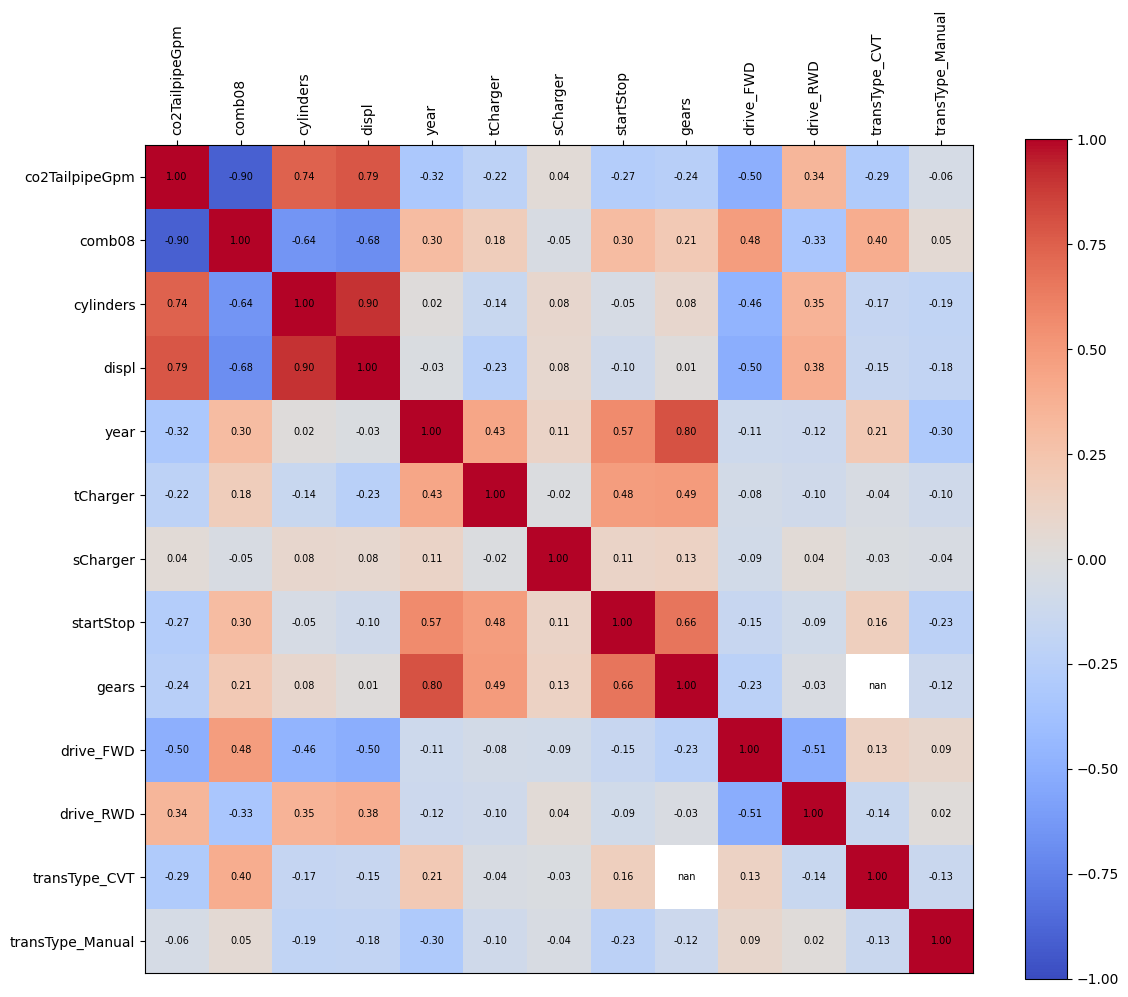

In [45]:
corr = df3.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('corr_matrix_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

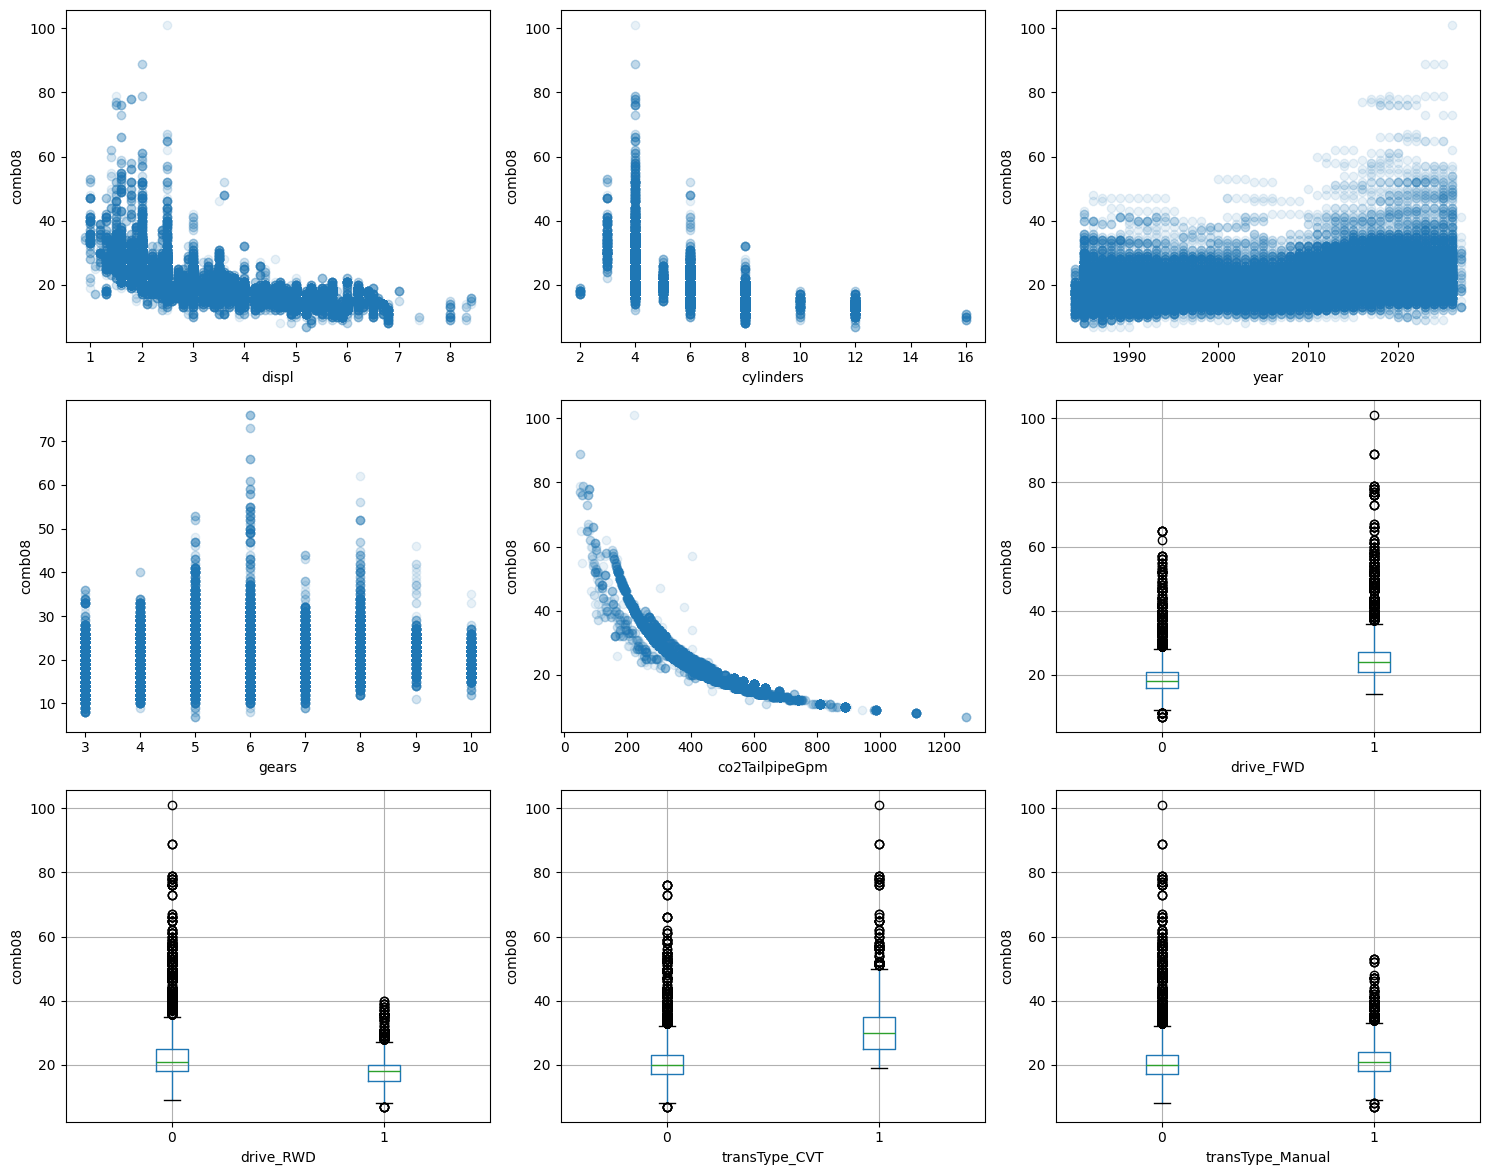

In [46]:
numericas = ['displ', 'cylinders', 'year', 'gears', 'co2TailpipeGpm']
dummies = ['drive_FWD', 'drive_RWD', 'transType_CVT', 'transType_Manual']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].scatter(df3[col], df3['comb08'], alpha=0.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('comb08')

for i, col in enumerate(dummies):
    ax = axes[len(numericas) + i]
    df3.boxplot(column='comb08', by=col, ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel('comb08')
    ax.set_title('')

plt.suptitle('')
plt.tight_layout()
plt.show()

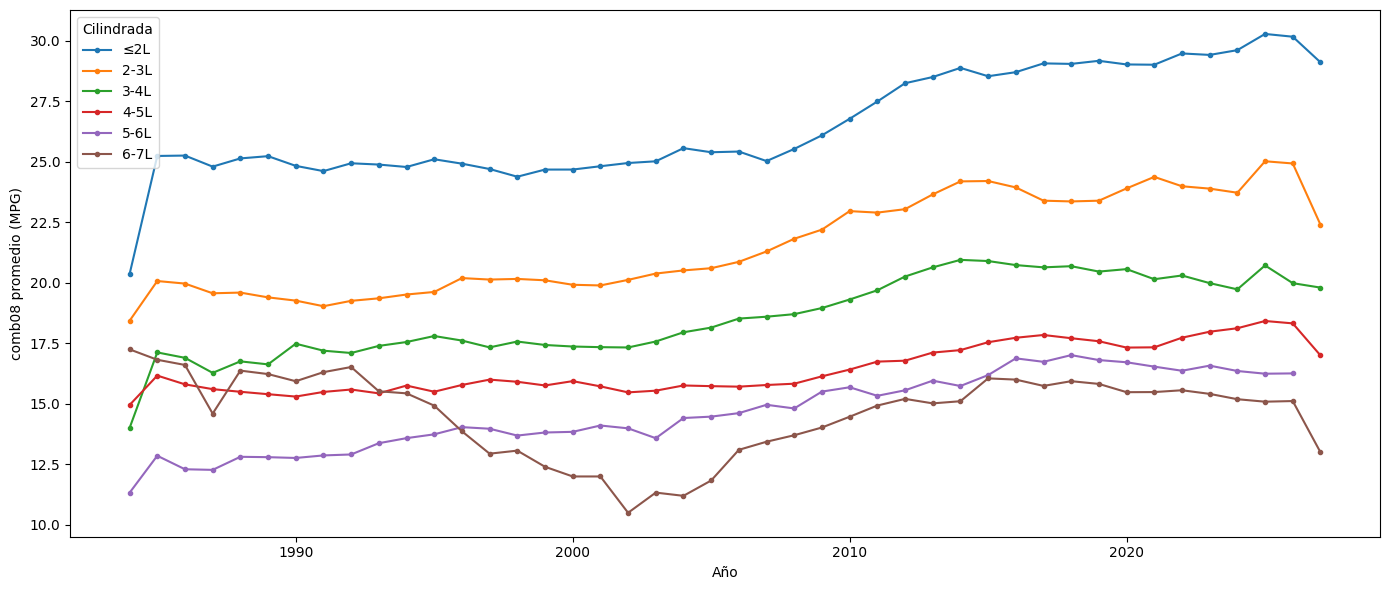

In [48]:
df3['displ_grupo'] = pd.cut(df3['displ'], 
                             bins=[0, 2, 3, 4, 5, 6, 7], 
                             labels=['≤2L', '2-3L', '3-4L', '4-5L', '5-6L', '6-7L'])

evolucion = df3.groupby(['year', 'displ_grupo'])['comb08'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for grupo in evolucion['displ_grupo'].cat.categories:
    datos = evolucion[evolucion['displ_grupo'] == grupo]
    ax.plot(datos['year'], datos['comb08'], label=grupo, marker='o', markersize=3)

ax.set_xlabel('Año')
ax.set_ylabel('comb08 promedio (MPG)')
ax.legend(title='Cilindrada')
plt.tight_layout()
plt.show()

In [49]:
df3.describe()

,co2TailpipeGpm,comb08,cylinders,displ,year,tCharger,sCharger,startStop,phevComb,gears,drive_FWD,drive_RWD,transType_CVT,transType_Manual
count,46012.000000,46012.000000,46012.000000,46012.000000,46012.000000,46012.000000,46012.000000,46012.000000,46012.000000,43929.000000,46012.000000,46012.000000,46012.000000,46012.000000
mean,457.437765,20.857037,5.699709,3.264859,2005.311484,0.241480,0.024733,0.178127,0.360406,5.479751,0.338999,0.335282,0.045271,0.271755
std,120.088747,6.018647,1.777352,1.346281,12.417118,0.427986,0.155311,0.382624,4.113351,1.654906,0.473374,0.472094,0.207900,0.444869
min,50.000000,7.000000,2.000000,0.900000,1984.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,376.000000,17.000000,4.000000,2.100000,1994.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,444.350000,20.000000,6.000000,3.000000,2006.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,522.764706,24.000000,6.000000,4.200000,2016.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,0.000000,1.000000
max,1269.571429,101.000000,16.000000,8.400000,2027.000000,1.000000,1.000000,1.000000,101.000000,10.000000,1.000000,1.000000,1.000000,1.000000


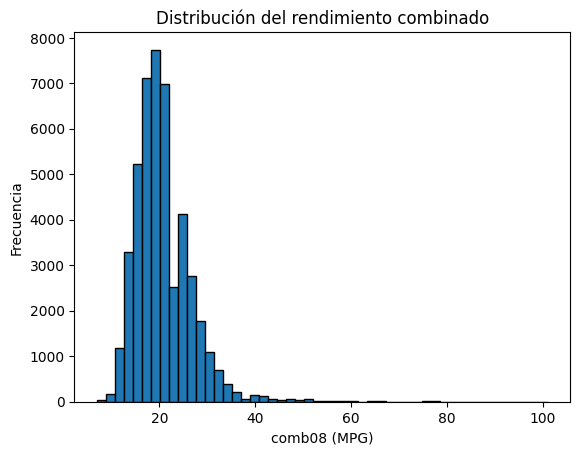

In [50]:
plt.hist(df3['comb08'], bins=50, edgecolor='black')
plt.xlabel('comb08 (MPG)')
plt.ylabel('Frecuencia')
plt.title('Distribución del rendimiento combinado')
plt.show()

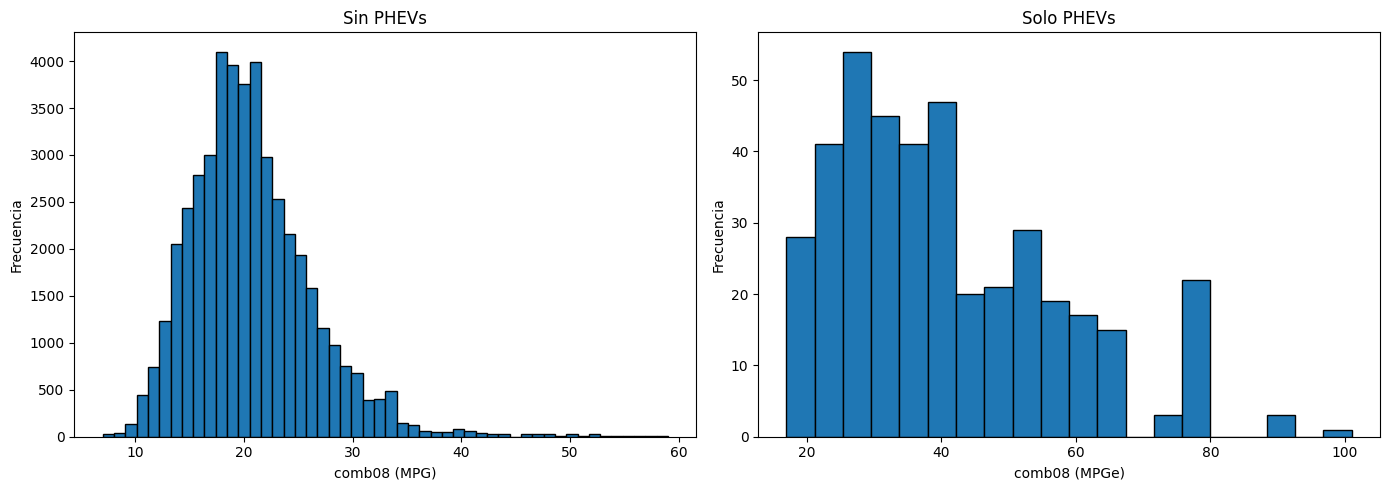

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin PHEVs
axes[0].hist(df3[df3['atvType'] != 'Plug-in Hybrid']['comb08'], bins=50, edgecolor='black')
axes[0].set_xlabel('comb08 (MPG)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Sin PHEVs')

# Solo PHEVs
axes[1].hist(df3[df3['atvType'] == 'Plug-in Hybrid']['comb08'], bins=20, edgecolor='black')
axes[1].set_xlabel('comb08 (MPGe)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Solo PHEVs')

plt.tight_layout()
plt.show()

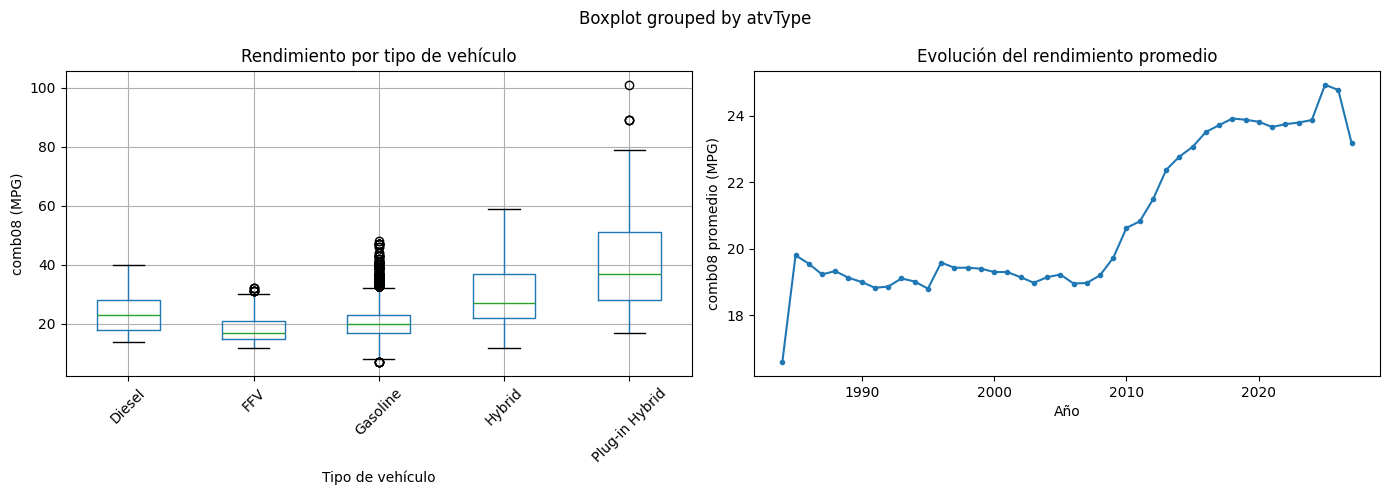

In [54]:
# Boxplot comb08 por atvType
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df3.boxplot(column='comb08', by='atvType', ax=axes[0])
axes[0].set_xlabel('Tipo de vehículo')
axes[0].set_ylabel('comb08 (MPG)')
axes[0].set_title('Rendimiento por tipo de vehículo')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Evolución temporal
evolucion_general = df3.groupby('year')['comb08'].mean().reset_index()
axes[1].plot(evolucion_general['year'], evolucion_general['comb08'], marker='o', markersize=3)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('comb08 promedio (MPG)')
axes[1].set_title('Evolución del rendimiento promedio')

plt.tight_layout()
plt.show()

In [55]:
df3.to_csv('vehicles_clean.csv', index=False)